In [5]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all three datasets
matches = pd.read_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\matches_cleaned.csv")

deliveries = pd.read_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\deliveries_cleaned.csv")

news_df = pd.read_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\cricket_news_sentiment.csv")

print("✅ All datasets loaded!")
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)
print("News:", news_df.shape)

✅ All datasets loaded!
Matches: (1095, 20)
Deliveries: (260920, 18)
News: (99, 7)


In [2]:
# Step 38: Calculate team performance scores
# Win rate for each team
total_matches = pd.concat([
    matches[['team1']].rename(columns={'team1': 'team'}),
    matches[['team2']].rename(columns={'team2': 'team'})
]).value_counts().reset_index()
total_matches.columns = ['team', 'total_matches']

total_wins = matches['winner'].value_counts().reset_index()
total_wins.columns = ['team', 'wins']

# Merge
team_performance = total_matches.merge(total_wins, on='team', how='left')
team_performance['win_rate'] = (team_performance['wins'] / team_performance['total_matches'] * 100).round(2)
team_performance = team_performance.sort_values('win_rate', ascending=False)

# Filter current IPL teams only
current_teams = [
    'Mumbai Indians', 'Chennai Super Kings', 
    'Royal Challengers Bengaluru', 'Royal Challengers Bangalore',
    'Kolkata Knight Riders', 'Delhi Capitals',
    'Rajasthan Royals', 'Sunrisers Hyderabad',
    'Punjab Kings', 'Lucknow Super Giants',
    'Gujarat Titans', 'Kings XI Punjab'
]

team_performance = team_performance[team_performance['team'].isin(current_teams)]

print("✅ Team Performance Scores:")
print(team_performance[['team', 'total_matches', 'wins', 'win_rate']].to_string(index=False))

✅ Team Performance Scores:
                       team  total_matches  wins  win_rate
             Gujarat Titans             45    28     62.22
        Chennai Super Kings            238   138     57.98
             Mumbai Indians            261   144     55.17
       Lucknow Super Giants             44    24     54.55
             Delhi Capitals             91    48     52.75
      Kolkata Knight Riders            251   131     52.19
           Rajasthan Royals            221   112     50.68
        Sunrisers Hyderabad            182    88     48.35
Royal Challengers Bangalore            240   116     48.33
Royal Challengers Bengaluru             15     7     46.67
            Kings XI Punjab            190    88     46.32
               Punjab Kings             56    24     42.86


In [3]:
# Step 39: Count team mentions in news
team_short = {
    'Mumbai Indians': ['Mumbai', 'MI'],
    'Chennai Super Kings': ['Chennai', 'CSK'],
    'Royal Challengers Bangalore': ['RCB', 'Bangalore', 'Bengaluru'],
    'Royal Challengers Bengaluru': ['RCB', 'Bangalore', 'Bengaluru'],
    'Kolkata Knight Riders': ['Kolkata', 'KKR'],
    'Delhi Capitals': ['Delhi', 'DC'],
    'Rajasthan Royals': ['Rajasthan', 'RR'],
    'Sunrisers Hyderabad': ['Hyderabad', 'SRH'],
    'Punjab Kings': ['Punjab', 'PBKS'],
    'Kings XI Punjab': ['Punjab', 'KXIP'],
    'Lucknow Super Giants': ['Lucknow', 'LSG'],
    'Gujarat Titans': ['Gujarat', 'GT']
}

def find_team(title):
    title = str(title)
    for team, keywords in team_short.items():
        for keyword in keywords:
            if keyword.lower() in title.lower():
                return team
    return 'General'

news_df['team_mentioned'] = news_df['title'].apply(find_team)

print("Team mentions in news:")
print(news_df['team_mentioned'].value_counts())

Team mentions in news:
team_mentioned
Mumbai Indians                 28
General                        28
Royal Challengers Bangalore    16
Kolkata Knight Riders           7
Sunrisers Hyderabad             7
Chennai Super Kings             5
Rajasthan Royals                3
Lucknow Super Giants            3
Delhi Capitals                  1
Gujarat Titans                  1
Name: count, dtype: int64


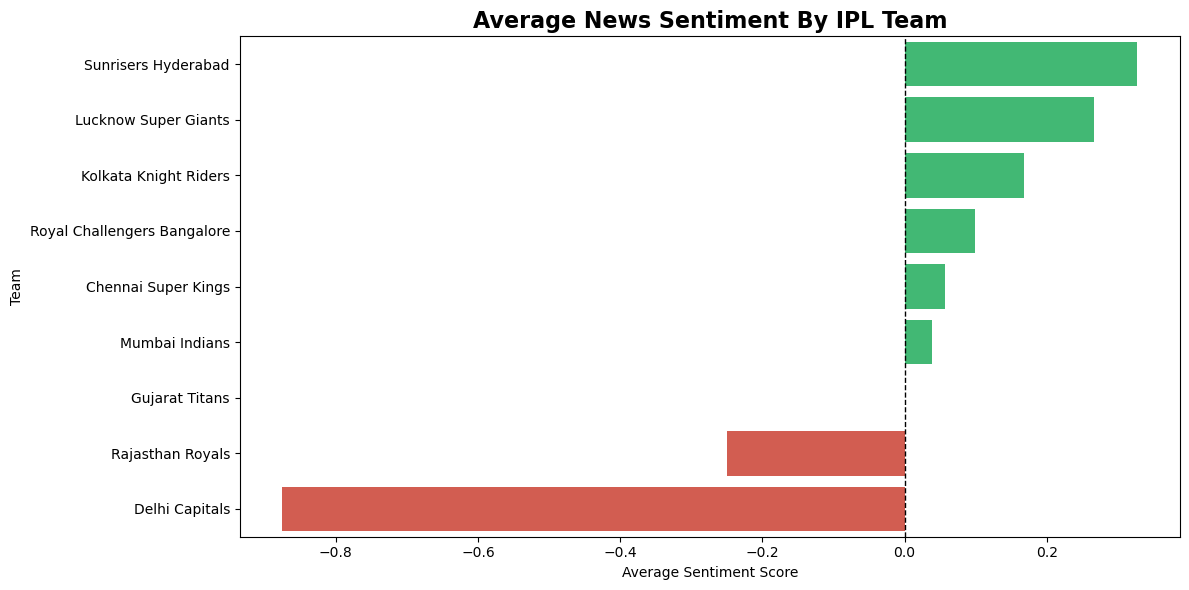

                          team  avg_sentiment
0          Sunrisers Hyderabad       0.327273
1         Lucknow Super Giants       0.266667
2        Kolkata Knight Riders       0.168615
3  Royal Challengers Bangalore       0.098891
4          Chennai Super Kings       0.057273
5               Mumbai Indians       0.039141
6               Gujarat Titans       0.000000
7             Rajasthan Royals      -0.250000
8               Delhi Capitals      -0.875000


In [4]:
# Step 40: Average sentiment by team
team_sentiment = news_df[news_df['team_mentioned'] != 'General'].groupby('team_mentioned')['polarity_score'].mean().sort_values(ascending=False).reset_index()
team_sentiment.columns = ['team', 'avg_sentiment']

plt.figure(figsize=(12,6))
colors = ['#2ECC71' if x > 0 else '#E74C3C' 
          for x in team_sentiment['avg_sentiment']]

sns.barplot(data=team_sentiment, x='avg_sentiment', y='team',
            hue='team', palette=dict(zip(team_sentiment['team'], colors)),
            legend=False)

plt.title('Average News Sentiment By IPL Team',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Team')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\team_sentiment.png")
plt.show()

print(team_sentiment)

In [6]:
print("test")

test


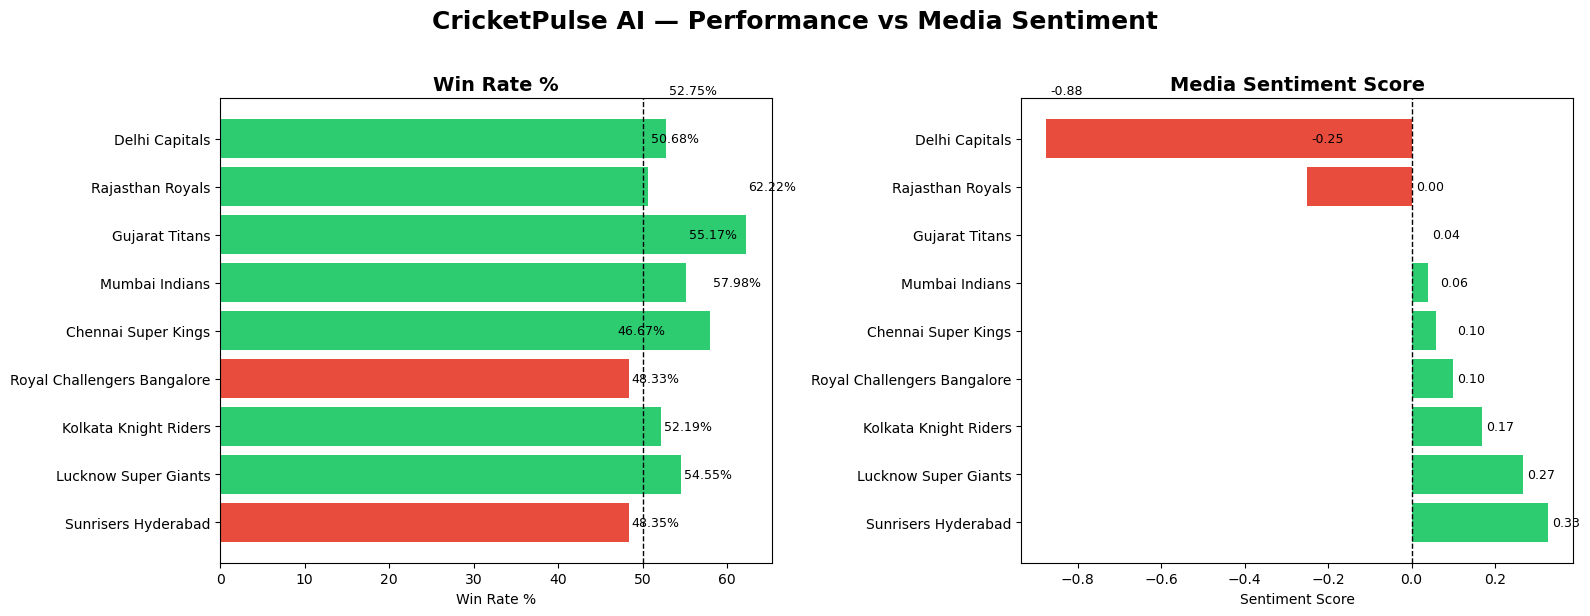

✅ Combined chart saved!


In [7]:
# Step 41: Performance vs Sentiment Combined Chart
# Merge team performance with sentiment
team_perf_filtered = team_performance[
    ['team', 'win_rate']].copy()

# Standardize RCB name
team_perf_filtered['team'] = team_perf_filtered['team'].replace(
    'Royal Challengers Bengaluru', 
    'Royal Challengers Bangalore')

combined = team_sentiment.merge(
    team_perf_filtered, on='team', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CricketPulse AI — Performance vs Media Sentiment',
             fontsize=18, fontweight='bold', y=1.02)

# Chart 1: Win Rate
colors_wr = ['#2ECC71' if x > 50 else '#E74C3C' 
             for x in combined['win_rate']]
axes[0].barh(combined['team'], combined['win_rate'],
             color=colors_wr)
axes[0].set_title('Win Rate %', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Win Rate %')
axes[0].axvline(x=50, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(combined['win_rate']):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

# Chart 2: Sentiment
colors_sent = ['#2ECC71' if x > 0 else '#E74C3C' 
               for x in combined['avg_sentiment']]
axes[1].barh(combined['team'], combined['avg_sentiment'],
             color=colors_sent)
axes[1].set_title('Media Sentiment Score', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment Score')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(combined['avg_sentiment']):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\performance_vs_sentiment.png",
            bbox_inches='tight')
plt.show()

print("✅ Combined chart saved!")

In [8]:
# Step 42: CSK Special Analysis 💛
csk_matches = matches[
    (matches['team1'] == 'Chennai Super Kings') | 
    (matches['team2'] == 'Chennai Super Kings')
]

csk_wins = matches[matches['winner'] == 'Chennai Super Kings']

print("💛 CSK SPECIAL ANALYSIS 💛")
print("="*40)
print(f"Total matches played: {len(csk_matches)}")
print(f"Total wins: {len(csk_wins)}")
print(f"Win rate: {len(csk_wins)/len(csk_matches)*100:.2f}%")

csk_season_wins = csk_wins.groupby('season').size()
print(f"\nBest season: {csk_season_wins.idxmax()} ({csk_season_wins.max()} wins)")
print(f"Worst season: {csk_season_wins.idxmin()} ({csk_season_wins.min()} wins)")

csk_toss = csk_matches[csk_matches['toss_winner'] == 'Chennai Super Kings']
csk_toss_wins = csk_toss[csk_toss['winner'] == 'Chennai Super Kings']
print(f"\nWhen CSK wins toss they win: {len(csk_toss_wins)/len(csk_toss)*100:.2f}% of matches")
print(f"CSK favourite toss decision: {csk_toss['toss_decision'].mode()[0]}")

print(f"\nBiggest win by runs: {csk_wins[csk_wins['result']=='runs']['result_margin'].max()} runs")
print(f"Biggest win by wickets: {int(csk_wins[csk_wins['result']=='wickets']['result_margin'].max())} wickets")

💛 CSK SPECIAL ANALYSIS 💛
Total matches played: 238
Total wins: 138
Win rate: 57.98%

Best season: 2021 (17 wins)
Worst season: 2022 (4 wins)

When CSK wins toss they win: 61.48% of matches
CSK favourite toss decision: field

Biggest win by runs: 97.0 runs
Biggest win by wickets: 10 wickets


C:\Users\Shruti Kumari Pandey\AppData\Local\Temp\ipykernel_30428\1310276731.py:18: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Shruti Kumari Pandey\AppData\Local\Temp\ipykernel_30428\1310276731.py:19: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from font(s) DejaVu Sans.
  plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\csk_top_batsmen.png")
C:\Users\Shruti Kumari Pandey\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


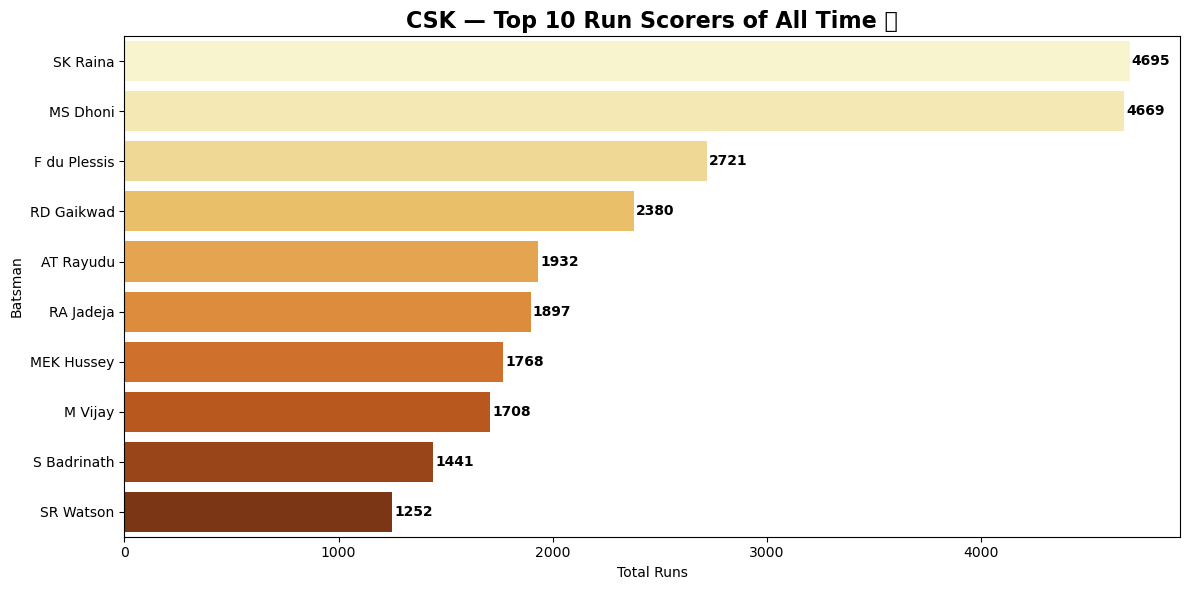

batter
SK Raina        4695
MS Dhoni        4669
F du Plessis    2721
RD Gaikwad      2380
AT Rayudu       1932
RA Jadeja       1897
MEK Hussey      1768
M Vijay         1708
S Badrinath     1441
SR Watson       1252
Name: batsman_runs, dtype: int64


In [9]:
# Step 43: CSK Top Batsmen
csk_batting = deliveries[deliveries['batting_team'] == 'Chennai Super Kings']

csk_top_batsmen = csk_batting.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=csk_top_batsmen.values, y=csk_top_batsmen.index,
            hue=csk_top_batsmen.index, palette='YlOrBr', legend=False)

plt.title('CSK — Top 10 Run Scorers of All Time 💛',
          fontsize=16, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')

for i, v in enumerate(csk_top_batsmen.values):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\csk_top_batsmen.png")
plt.show()

print(csk_top_batsmen)

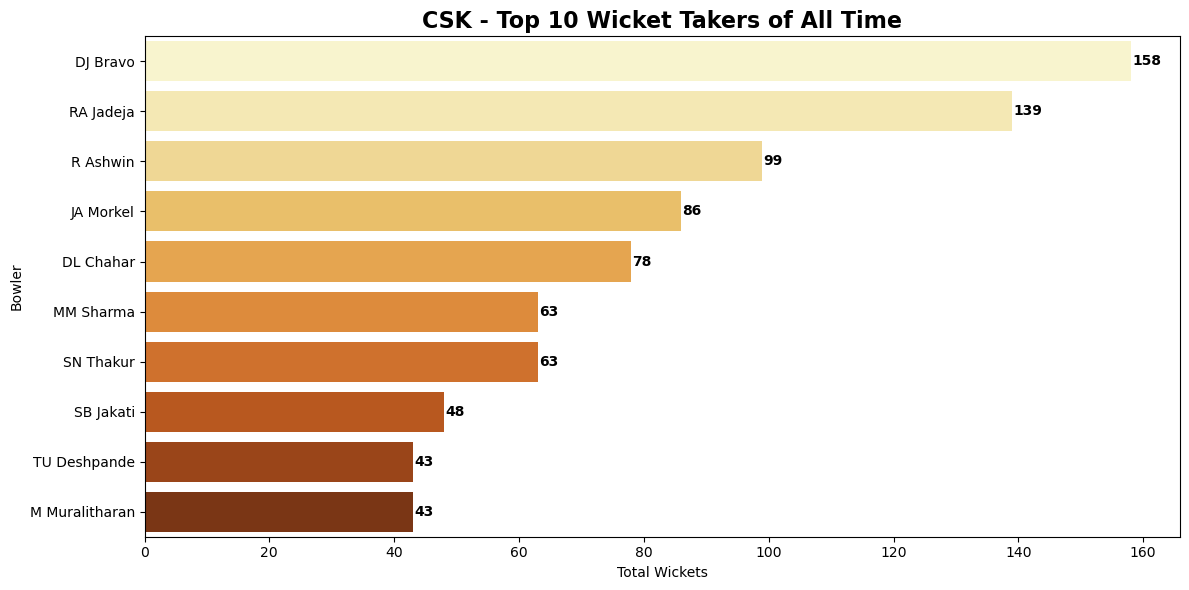

bowler
DJ Bravo          158
RA Jadeja         139
R Ashwin           99
JA Morkel          86
DL Chahar          78
MM Sharma          63
SN Thakur          63
SB Jakati          48
TU Deshpande       43
M Muralitharan     43
Name: is_wicket, dtype: int64


In [10]:
# Step 44: CSK Top Bowlers
csk_bowling = deliveries[
    (deliveries['bowling_team'] == 'Chennai Super Kings') & 
    (deliveries['is_wicket'] == 1)
]

csk_top_bowlers = csk_bowling.groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=csk_top_bowlers.values, y=csk_top_bowlers.index,
            hue=csk_top_bowlers.index, palette='YlOrBr', legend=False)

plt.title('CSK - Top 10 Wicket Takers of All Time',
          fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')

for i, v in enumerate(csk_top_bowlers.values):
    plt.text(v + 0.2, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\csk_top_bowlers.png")
plt.show()

print(csk_top_bowlers)

C:\Users\Shruti Kumari Pandey\AppData\Local\Temp\ipykernel_30428\901255564.py:25: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Shruti Kumari Pandey\AppData\Local\Temp\ipykernel_30428\901255564.py:26: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\csk_season_wins.png")
C:\Users\Shruti Kumari Pandey\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


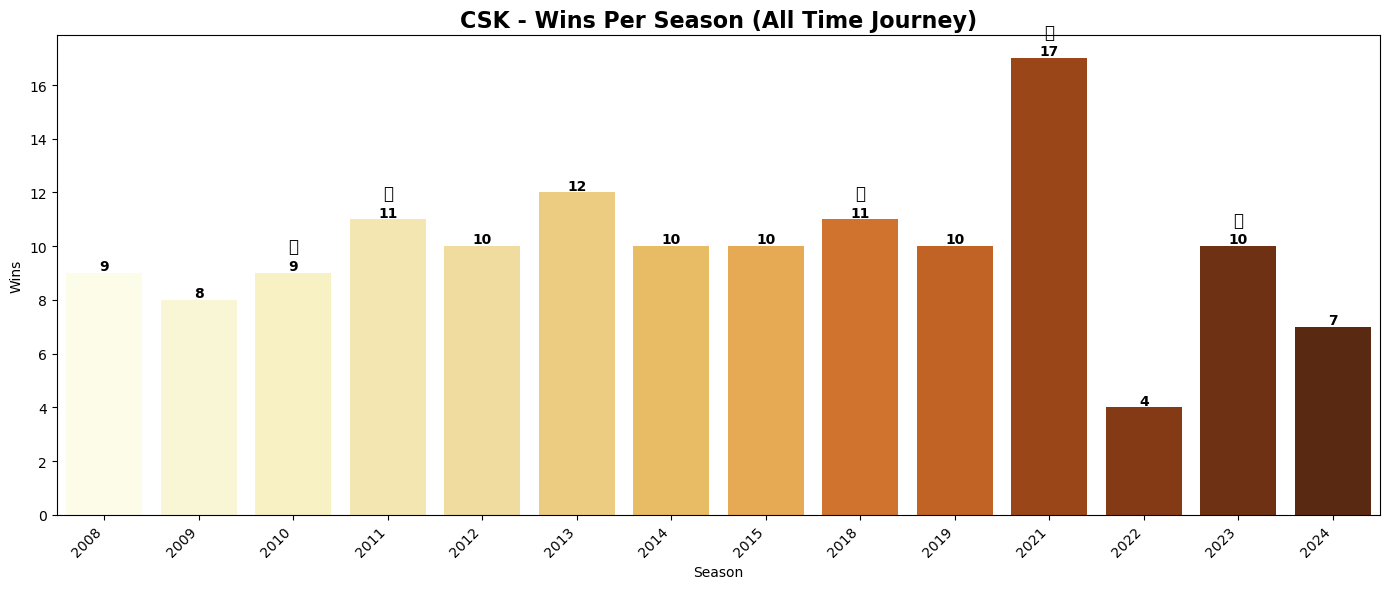

    season  wins
0     2008     9
1     2009     8
2     2010     9
3     2011    11
4     2012    10
5     2013    12
6     2014    10
7     2015    10
8     2018    11
9     2019    10
10    2021    17
11    2022     4
12    2023    10
13    2024     7


In [11]:
# Step 45: CSK wins per season
csk_season = csk_wins.groupby('season').size().reset_index(name='wins')

plt.figure(figsize=(14,6))
bars = sns.barplot(data=csk_season, x='season', y='wins',
            hue='season', palette='YlOrBr', legend=False)

plt.title('CSK - Wins Per Season (All Time Journey)',
          fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')

for i, row in csk_season.iterrows():
    plt.text(i, row['wins'] + 0.1, str(row['wins']),
             ha='center', fontweight='bold', fontsize=10)

# Highlight title winning seasons
title_seasons = ['2010', '2011', '2018', '2021', '2023']
for i, row in csk_season.iterrows():
    if str(row['season']) in title_seasons:
        plt.text(i, row['wins'] + 0.8, '🏆',
                ha='center', fontsize=12)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\csk_season_wins.png")
plt.show()

print(csk_season)

In [12]:
# Step 46: CSK Analysis without ban years
print("💛 CSK STATS WITH BAN IMPACT ANALYSIS")
print("="*45)

# Seasons played
total_ipl_seasons = 17  # 2008 to 2024
csk_seasons_played = 14  # missed 2016, 2017, 2020 (COVID - UAE)
csk_seasons_missed = 2   # only ban years count

print(f"Total IPL seasons: {total_ipl_seasons}")
print(f"CSK seasons played: {csk_seasons_played}")
print(f"Seasons missed due to ban: {csk_seasons_missed}")

# Avg wins per season
avg_wins = len(csk_wins) / csk_seasons_played
print(f"\nCSK average wins per season: {avg_wins:.2f}")

# Projected wins if they played all seasons
projected_wins = avg_wins * total_ipl_seasons
print(f"Projected wins if no ban: {projected_wins:.0f}")

# Compare with MI
mi_wins = len(matches[matches['winner'] == 'Mumbai Indians'])
print(f"\nMumbai Indians actual wins: {mi_wins}")
print(f"CSK actual wins: {len(csk_wins)}")
print(f"CSK projected wins (no ban): {projected_wins:.0f}")
print(f"Difference vs MI: {projected_wins - mi_wins:.0f} wins")

💛 CSK STATS WITH BAN IMPACT ANALYSIS
Total IPL seasons: 17
CSK seasons played: 14
Seasons missed due to ban: 2

CSK average wins per season: 9.86
Projected wins if no ban: 168

Mumbai Indians actual wins: 144
CSK actual wins: 138
CSK projected wins (no ban): 168
Difference vs MI: 24 wins


In [13]:
# Step 47: Save CSK analysis summary
csk_summary = {
    'total_matches': len(csk_matches),
    'total_wins': len(csk_wins),
    'win_rate': round(len(csk_wins)/len(csk_matches)*100, 2),
    'avg_wins_per_season': round(avg_wins, 2),
    'projected_wins_no_ban': round(projected_wins, 0),
    'top_batsman': 'SK Raina (4695 runs)',
    'top_bowler': 'DJ Bravo (158 wickets)',
    'best_season': '2021 (17 wins)',
    'worst_season': '2022 (4 wins)'
}

import json
with open(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\csk_analysis.json", 'w') as f:
    json.dump(csk_summary, f, indent=4)

print("✅ CSK Analysis saved!")
print("\nCSK Summary:")
for key, value in csk_summary.items():
    print(f"{key}: {value}")

✅ CSK Analysis saved!

CSK Summary:
total_matches: 238
total_wins: 138
win_rate: 57.98
avg_wins_per_season: 9.86
projected_wins_no_ban: 168.0
top_batsman: SK Raina (4695 runs)
top_bowler: DJ Bravo (158 wickets)
best_season: 2021 (17 wins)
worst_season: 2022 (4 wins)


In [14]:
# Batting position & strike rate analysis
# Calculate average batting position
batting_position = deliveries.groupby(['match_id', 'batter']).agg(
    first_ball=('ball', 'min'),
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

# Average stats per batsman
batsman_stats = batting_position.groupby('batter').agg(
    avg_position=('first_ball', 'mean'),
    total_runs=('total_runs', 'sum'),
    total_balls=('balls_faced', 'sum'),
    innings=('match_id', 'count')
).reset_index()

# Calculate strike rate and avg runs per innings
batsman_stats['strike_rate'] = (batsman_stats['total_runs'] / 
                                 batsman_stats['total_balls'] * 100).round(2)
batsman_stats['avg_runs_per_innings'] = (batsman_stats['total_runs'] / 
                                          batsman_stats['innings']).round(2)
batsman_stats['avg_balls_per_innings'] = (batsman_stats['total_balls'] / 
                                           batsman_stats['innings']).round(2)

# Filter top players only
top_players_list = ['V Kohli', 'MS Dhoni', 'RG Sharma', 
                    'DA Warner', 'S Dhawan', 'AB de Villiers',
                    'CH Gayle', 'SK Raina', 'AD Russell',
                    'KD Karthik']

comparison = batsman_stats[batsman_stats['batter'].isin(top_players_list)]
comparison = comparison.sort_values('total_runs', ascending=False)

print("="*85)
print(f"{'Player':<20} {'Total Runs':<12} {'Innings':<10} {'Avg Runs/Inn':<15} {'Avg Balls/Inn':<15} {'Strike Rate'}")
print("="*85)
for _, row in comparison.iterrows():
    print(f"{row['batter']:<20} {row['total_runs']:<12} {row['innings']:<10} {row['avg_runs_per_innings']:<15} {row['avg_balls_per_innings']:<15} {row['strike_rate']}")

Player               Total Runs   Innings    Avg Runs/Inn    Avg Balls/Inn   Strike Rate
V Kohli              8014         244        32.84           25.56           128.51
S Dhawan             6769         221        30.63           24.81           123.45
RG Sharma            6630         251        26.41           20.65           127.92
DA Warner            6567         184        35.69           26.35           135.43
SK Raina             5536         200        27.68           20.88           132.54
MS Dhoni             5243         228        23.0            17.31           132.84
AB de Villiers       5181         170        30.48           20.51           148.58
CH Gayle             4997         141        35.44           24.94           142.12
KD Karthik           4843         233        20.79           15.82           131.35
AD Russell           2488         104        23.92           14.57           164.22


In [15]:
# Save batting comparison
comparison.to_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\batting_comparison.csv", index=False)
print("✅ Batting comparison saved!")

✅ Batting comparison saved!
